## Course development analysis
This project focuses on the development of the courses, esp. their enrolments and acquired certificats 

In [1]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import re
from datetime import timedelta

In [2]:
# Use the cleaned Excel sheet!!!
# define a list of sheet names

dates_str = ['29.06.2026', '28.05.2026', '27.04.2026', '27.03.2026', '27.02.2026', '28.01.2026', '19.12.2025', '27.11.2025', '28.10.2025', '26.09.2025', '26.08.2025', '28.07.2025', '23.06.2025', '21.05.2025']


In [3]:
# import data by looping over the sheet names

course_df = pd.DataFrame()

for sheet_str in dates_str:
    import_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Course_success_tracking/course_success_tracking.xlsx'
    df = pd.read_excel(import_path, sheet_name = sheet_str)
    df['date'] = sheet_str
    df['date'] =  pd.to_datetime(df['date'], format = '%d.%m.%Y')
    df['month'] = df['date'].dt.month
    course_df = pd.concat([course_df, df], axis = 0, ignore_index = True) 
    
course_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   courseID                                   1254 non-null   int64         
 1   Live Courses                               1254 non-null   object        
 2   Course Category                            1254 non-null   object        
 3   Enrolled learners                          1254 non-null   int64         
 4   Acquired # Comfirmation of Participations  1241 non-null   float64       
 5   Acquired # Records of Achievement          1235 non-null   float64       
 6   Rate CoP                                   1249 non-null   float64       
 7   Rate RoA (success)                         1247 non-null   float64       
 8   date                                       1254 non-null   datetime64[ns]
 9   month              

In [4]:
# change the column names --> too wordy

course_df.columns = ['courseID', 'Live Courses', 'Course Category', 'Enrolled learners', 'CoP', 'RoA', 'Rate CoP', 'Rate RoA', 'date', 'month']

course_df.head()


,courseID,Live Courses,Course Category,Enrolled learners,CoP,RoA,Rate CoP,Rate RoA,date,month
0,106,Einführung in die KI,Über KI,22405,3587.0,2916.0,0.160098,0.130150,2026-06-29,6
1,58,AICE your exams – Generative KI als Copilot im...,Studieren,14411,9940.0,5485.0,0.689751,0.380612,2026-06-29,6
2,99,KI für Alle 1: Einführung in die Künstliche In...,Über KI,9637,820.0,625.0,0.085089,0.064854,2026-06-29,6
3,313,EU AI Act Essentials,Studieren,9611,3463.0,2685.0,0.360316,0.279367,2026-06-29,6
4,197,KIÖV - KI in öffentlichen Verwaltungen,Studieren,6766,3373.0,2913.0,0.498522,0.430535,2026-06-29,6


In [5]:
# exclude courses off public catalogue:
#automl_id = 245
#produktki_id = 176
#amalea_id = 251
#launchpad_id = 95

#course_df = course_df.loc[~(course_df['courseID'] == automl_id) & ~(course_df['courseID'] == produktki_id) & ~(course_df['courseID'] == amalea_id) & ~(course_df['courseID'] == 95)]

course_df.shape


(1254, 10)

In [6]:
# the latest date for indexing
latest_date = course_df.loc[:, 'date'][0]

latest_date

Timestamp('2026-06-29 00:00:00')

## Enrolment & certificates

In [7]:
# create table of enrolment

monthly_enrol = course_df.groupby('date')[['Enrolled learners', 'CoP', 'RoA']].agg(sum)

monthly_enrol


C:\Users\ywa\AppData\Local\Temp\ipykernel_14056\834444531.py:3: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  monthly_enrol = course_df.groupby('date')[['Enrolled learners', 'CoP', 'RoA']].agg(sum)


,Enrolled learners,CoP,RoA
date,,,
2025-05-21,55507,8893.0,6840.0
2025-06-23,61764,10380.0,7938.0
2025-07-28,69711,12154.0,9359.0
2025-08-26,76808,13843.0,10756.0
2025-09-26,86982,15783.0,12284.0
2025-10-28,99671,17950.0,14051.0
2025-11-27,111626,20839.0,16425.0
2025-12-19,122197,24159.0,18930.0
2026-01-28,140990,33822.0,25666.0


In [8]:
# calculate the changes per month --> via function 

def rate_enrol_cert(df):
    df['change_enrol'] = df['Enrolled learners'].pct_change()
    df['change_CoP'] = df['CoP'].pct_change()
    df['change_RoA'] = df['RoA'].pct_change()
    return df

monthly_enrol = rate_enrol_cert(monthly_enrol)

monthly_enrol


,Enrolled learners,CoP,RoA,change_enrol,change_CoP,change_RoA
date,,,,,,
2025-05-21,55507,8893.0,6840.0,NaN,NaN,NaN
2025-06-23,61764,10380.0,7938.0,0.112725,0.167210,0.160526
2025-07-28,69711,12154.0,9359.0,0.128667,0.170906,0.179012
2025-08-26,76808,13843.0,10756.0,0.101806,0.138967,0.149268
2025-09-26,86982,15783.0,12284.0,0.132460,0.140143,0.142060
2025-10-28,99671,17950.0,14051.0,0.145881,0.137300,0.143846
2025-11-27,111626,20839.0,16425.0,0.119945,0.160947,0.168956
2025-12-19,122197,24159.0,18930.0,0.094700,0.159317,0.152511
2026-01-28,140990,33822.0,25666.0,0.153793,0.399975,0.355837


<Axes: >

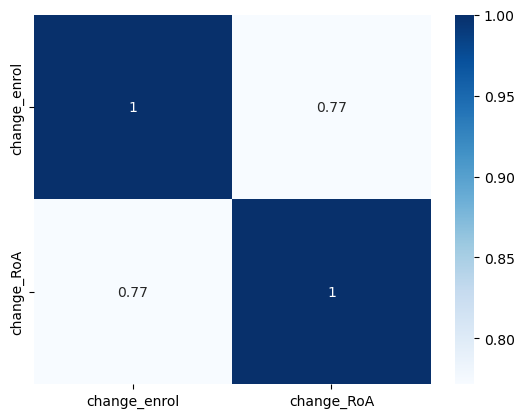

In [9]:
# rate correlation

enrol_cert_change = monthly_enrol[['change_enrol', 'change_RoA']].corr()

sns.heatmap(enrol_cert_change, annot = True, cmap = 'Blues') # moderate positive correalation between percentage of enrollment and percentage of RoA


In [10]:
# enrolment rate & RoA rate

print('The highest enrolment change was:',round(monthly_enrol['change_enrol'].max(), 2), 'in month', monthly_enrol['change_enrol'].idxmax())
print('The lowest enrolment change was:', round(monthly_enrol['change_enrol'].min(), 2), 'in month', monthly_enrol['change_enrol'].idxmin())

print('The highest RoA change was:',round(monthly_enrol['change_RoA'].max(), 2), 'in month', monthly_enrol['change_RoA'].idxmax())
print('The lowest RoA change was:', round(monthly_enrol['change_RoA'].min(), 2), 'in month', monthly_enrol['change_RoA'].idxmin())



The highest enrolment change was: 0.15 in month 2026-01-28 00:00:00
The lowest enrolment change was: 0.06 in month 2026-06-29 00:00:00
The highest RoA change was: 0.36 in month 2026-01-28 00:00:00
The lowest RoA change was: 0.08 in month 2026-04-27 00:00:00


C:\Users\ywa\AppData\Local\Temp\ipykernel_14056\1316578575.py:9: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(monthly_enrol.index, monthly_enrol["change_enrol"], color="blue", label="change_Enrolment", linestyle="-")
C:\Users\ywa\AppData\Local\Temp\ipykernel_14056\1316578575.py:10: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(monthly_enrol.index, monthly_enrol["change_RoA"], color="green", label="change_RoA", linestyle="-")


<Figure size 2400x800 with 0 Axes>

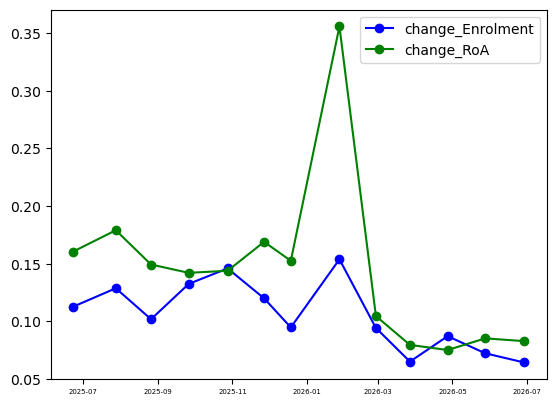

In [11]:
# plotting enrol rate & RoA rate

plt.figure(figsize = (24, 8))
fig, ax = plt.subplots()

x_col='Date'
y_col = 'Rate'

ax.plot_date(monthly_enrol.index, monthly_enrol["change_enrol"], color="blue", label="change_Enrolment", linestyle="-")
ax.plot_date(monthly_enrol.index, monthly_enrol["change_RoA"], color="green", label="change_RoA", linestyle="-")
ax.tick_params(axis='x', labelsize = 5)
#ax.xaxis.set_major_locator(MultipleLocator(30)) 

ax.legend()


# Correlation among all courses and roa

<Axes: xlabel='Enrolled learners', ylabel='RoA'>

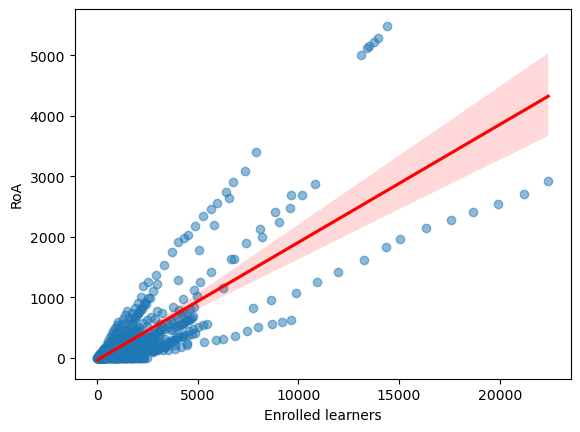

In [12]:
# Scatter plot

sns.regplot(data = course_df, x = 'Enrolled learners', y = 'RoA', scatter_kws = {'alpha' : 0.5}, line_kws = {'color' : 'red', 'label' : 'Trend line'})

In [13]:
# calculation of the correlation value
corr_enrol_roa = course_df['Enrolled learners'].corr(course_df['RoA'])

print('Correlation between enrolment and RoA:', corr_enrol_roa)

Correlation between enrolment and RoA: 0.8136645633205757


## top 10 Enrolments and RoA -- average growth

In [14]:
# group the table based on the courses

enrol_by_course = course_df.groupby(['courseID', 'Live Courses', 'Course Category'])[['Enrolled learners', 'RoA', 'Rate RoA']].agg(np.mean)

enrol_by_course.columns = ['Avg_enrol', 'Avg_RoA', 'Avg_rate_RoA']

enrol_by_course['Avg_enrol'] = round(enrol_by_course['Avg_enrol'], 0)

enrol_by_course['Avg_RoA'] = round(enrol_by_course['Avg_RoA'], 2)

enrol_by_course['Avg_rate_RoA'] = round(enrol_by_course['Avg_rate_RoA'], 2)

enrol_by_course_id = enrol_by_course.reset_index()

enrol_by_course = enrol_by_course_id.set_index('Live Courses')

enrol_by_course

C:\Users\ywa\AppData\Local\Temp\ipykernel_14056\575310330.py:3: FutureWarning: The provided callable <function mean at 0x0000023B37C9FEC0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  enrol_by_course = course_df.groupby(['courseID', 'Live Courses', 'Course Category'])[['Enrolled learners', 'RoA', 'Rate RoA']].agg(np.mean)


,courseID,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA
Live Courses,,,,,
Introduction to Machine Learning Part 1: Foundations,6,Maschinelles Lernen,1660.0,91.21,0.05
Dr. med. KI - Ethics,10,Medizin,636.0,183.50,0.28
Sprachassistenzen als Chance für die Hochschullehre,19,Erwachsenenbildung,4266.0,576.79,0.13
Identifikation geeigneter KI-Anwendungsfälle,27,Industrie 4.0,3799.0,299.71,0.08
Künstliche Intelligenz im Handel,28,Handel,1453.0,233.21,0.16
...,...,...,...,...,...
Agentic AI: The New Software Paradigm,393,Maschinelles Lernen,1469.0,146.00,0.09
Transformer-basierte Large Language Models verstehen,394,Maschinelles Lernen,732.0,51.67,0.07
Crafting Precision Prompts with GenAI,400,Über KI,1067.0,0.00,0.00


In [15]:
# plotting function

def plot_topX_horizontal(title, series, xlabel, x = 10, show_values = False):
    plt.figure(figsize = (14, 8))
    
    series = series.sort_values(ascending = False)
    ax = series.iloc[: x].iloc[: : -1].plot(kind="barh")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Course Name')
    plt.grid(axis = 'x')
    
    # show values
    if show_values == True:
        for bar in ax.patches:
            width = bar.get_width()
            y = bar.get_y() + bar.get_height() / 2
            ax.text(width, y, f'{width:.2f}', va = 'center', ha = 'left', color = 'black', fontweight = 'bold', fontsize = 10, clip_on = False)
        
    plt.tight_layout()
    plt.show()

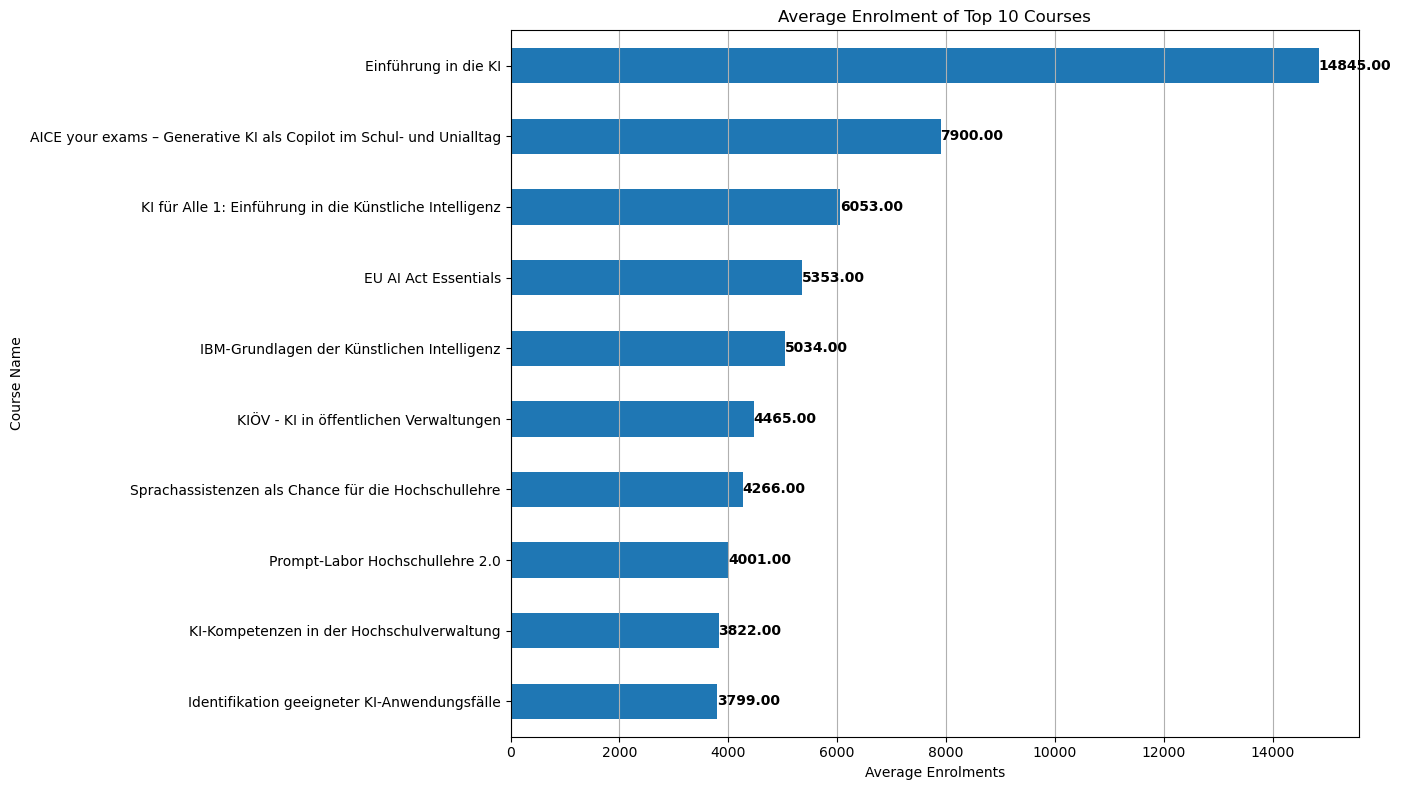

In [16]:
#  ranking base on the three differnt variables

# ranking based on Avg_enrol
plot_topX_horizontal('Average Enrolment of Top 10 Courses', enrol_by_course['Avg_enrol'], xlabel = 'Average Enrolments', show_values = True)


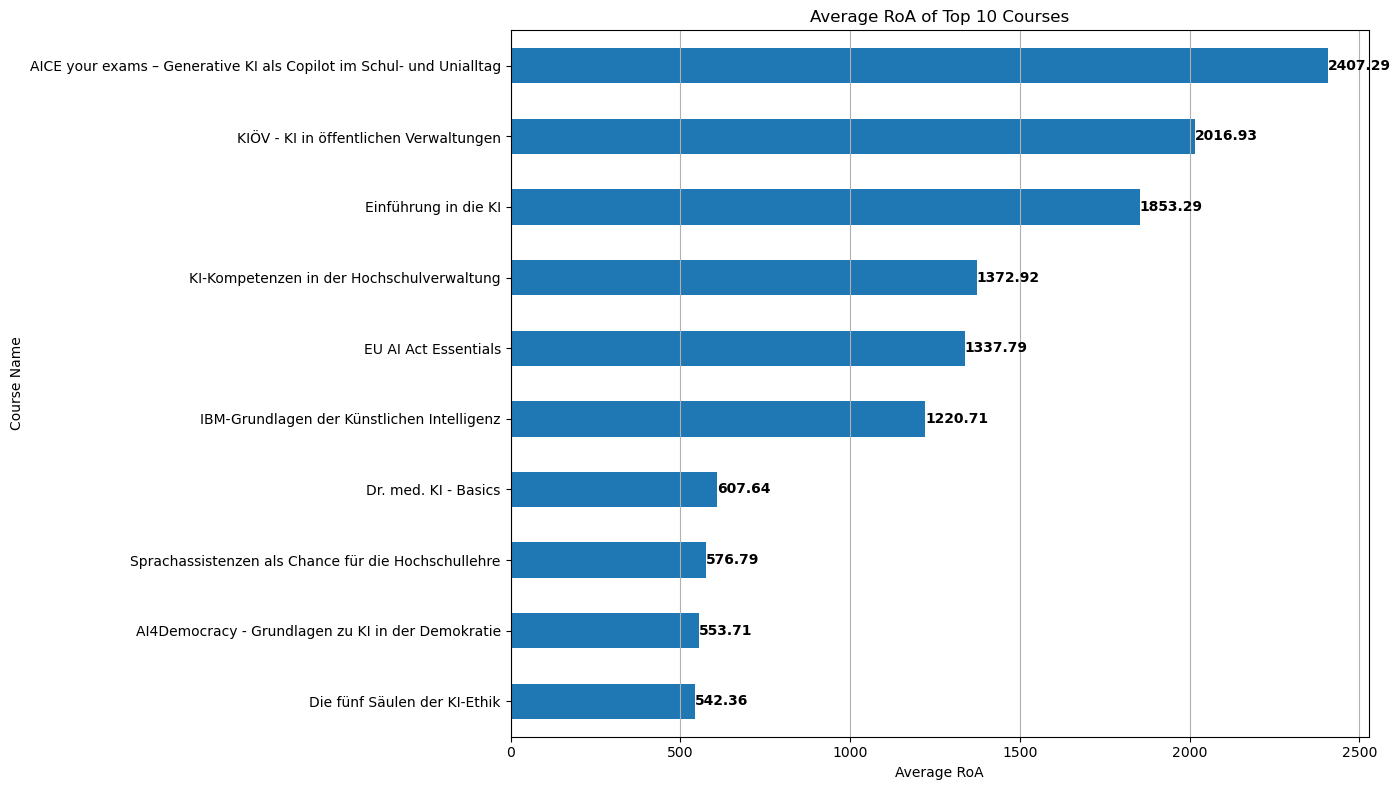

In [17]:
# ranking based on Avg_RoA
plot_topX_horizontal('Average RoA of Top 10 Courses', enrol_by_course['Avg_RoA'], xlabel = 'Average RoA', show_values = True)


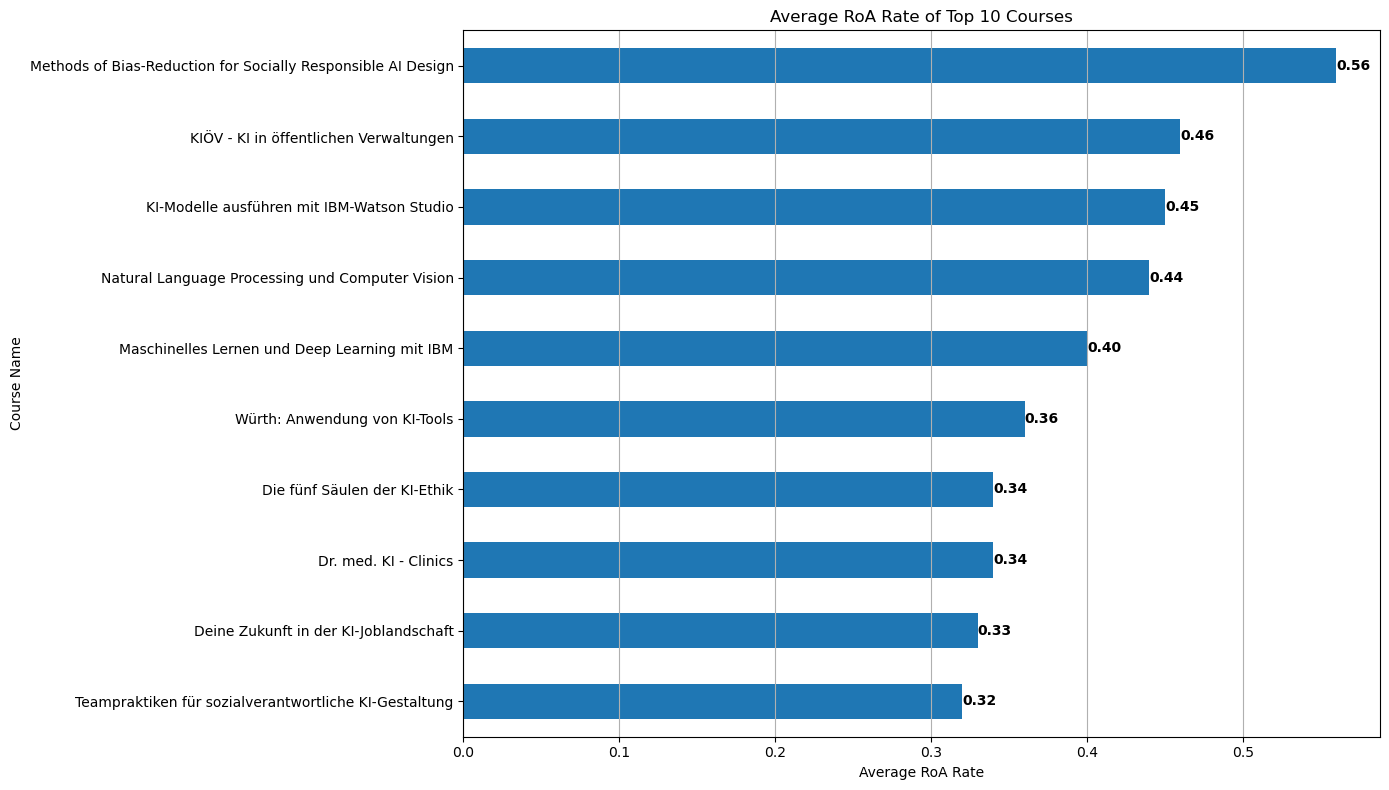

In [18]:
# Ranking based on RoA_Rate
plot_topX_horizontal('Average RoA Rate of Top 10 Courses', enrol_by_course['Avg_rate_RoA'], xlabel = 'Average RoA Rate', show_values = True)


## Time series of top 10

In [19]:
# getting indicies of the top 10 --> list of coures names

# avg enrol
top_10_enrol = enrol_by_course['Avg_enrol'].sort_values(ascending = False).head(10).index

# avg RoA
top_10_RoA = enrol_by_course['Avg_RoA'].sort_values(ascending = False).head(10).index

# avg rate RoA
top_10_rate_RoA = enrol_by_course['Avg_rate_RoA'].sort_values(ascending = False).head(10).index



In [20]:
# index top courses

# top enrol
top10_enrol_allTime = course_df[course_df['Live Courses'].isin(top_10_enrol)]

top10_enrol_allTime.head()

# pivot table

top10_enrol_allTime_pivot = top10_enrol_allTime.pivot(index = 'date', columns = 'Live Courses', values = 'Enrolled learners')

top10_enrol_allTime_pivot.head()


Live Courses,AICE your exams – Generative KI als Copilot im Schul- und Unialltag,EU AI Act Essentials,Einführung in die KI,IBM-Grundlagen der Künstlichen Intelligenz,Identifikation geeigneter KI-Anwendungsfälle,KI für Alle 1: Einführung in die Künstliche Intelligenz,KI-Kompetenzen in der Hochschulverwaltung,KIÖV - KI in öffentlichen Verwaltungen,Prompt-Labor Hochschullehre 2.0,Sprachassistenzen als Chance für die Hochschullehre
date,,,,,,,,,,
2025-05-21,2767.0,2113.0,7738.0,167.0,2691.0,2761.0,NaN,2273.0,2634.0,3652.0
2025-06-23,2920.0,2473.0,8631.0,430.0,2856.0,3026.0,NaN,2517.0,2770.0,3755.0
2025-07-28,3022.0,2895.0,9857.0,687.0,3067.0,3385.0,350.0,2919.0,2975.0,3919.0
2025-08-26,3146.0,3232.0,10916.0,871.0,3257.0,3881.0,847.0,3312.0,3167.0,4017.0
2025-09-26,3276.0,3747.0,11961.0,1632.0,3431.0,4484.0,1302.0,3718.0,3416.0,4109.0


In [21]:
# top RoA
top10_RoA_allTime = course_df[course_df['Live Courses'].isin(top_10_RoA)]

top10_RoA_allTime.head()

top10_RoA_allTime_pivot = top10_RoA_allTime.pivot(index = 'date', columns = 'Live Courses', values = 'RoA')

top10_RoA_allTime_pivot.head()

Live Courses,AI4Democracy - Grundlagen zu KI in der Demokratie,AICE your exams – Generative KI als Copilot im Schul- und Unialltag,Die fünf Säulen der KI-Ethik,Dr. med. KI - Basics,EU AI Act Essentials,Einführung in die KI,IBM-Grundlagen der Künstlichen Intelligenz,KI-Kompetenzen in der Hochschulverwaltung,KIÖV - KI in öffentlichen Verwaltungen,Sprachassistenzen als Chance für die Hochschullehre
date,,,,,,,,,,
2025-05-21,228.0,105.0,30.0,354.0,436.0,823.0,35.0,NaN,1186.0,460.0
2025-06-23,271.0,140.0,61.0,398.0,532.0,954.0,85.0,NaN,1249.0,479.0
2025-07-28,299.0,163.0,118.0,438.0,643.0,1081.0,168.0,45.0,1365.0,505.0
2025-08-26,331.0,183.0,177.0,480.0,744.0,1258.0,213.0,155.0,1532.0,526.0
2025-09-26,377.0,204.0,233.0,518.0,847.0,1414.0,318.0,253.0,1758.0,540.0


In [22]:
# top RoA Rate
top10_RoA_rate_allTime = course_df[course_df['Live Courses'].isin(top_10_rate_RoA)]

top10_RoA_rate_allTime.head()

top10_RoA_rate_allTime_pivot = top10_RoA_rate_allTime.pivot(index = 'date', columns = 'Live Courses', values = 'Rate RoA')

top10_RoA_rate_allTime_pivot.head()


Live Courses,Deine Zukunft in der KI-Joblandschaft,Die fünf Säulen der KI-Ethik,Dr. med. KI - Clinics,KI-Modelle ausführen mit IBM-Watson Studio,KIÖV - KI in öffentlichen Verwaltungen,Maschinelles Lernen und Deep Learning mit IBM,Methods of Bias-Reduction for Socially Responsible AI Design,Natural Language Processing und Computer Vision,Teampraktiken für sozialverantwortliche KI-Gestaltung,Würth: Anwendung von KI-Tools
date,,,,,,,,,,
2025-05-21,0.287500,0.256410,0.305556,0.000000,0.521777,0.300000,NaN,0.409091,0.331034,0.351852
2025-06-23,0.300971,0.251029,0.325843,0.301587,0.496226,0.313725,NaN,0.323810,0.328160,0.363229
2025-07-28,0.291066,0.293532,0.328165,0.411765,0.467626,0.388430,NaN,0.370787,0.315126,0.363229
2025-08-26,0.303093,0.311072,0.330144,0.451429,0.462560,0.423295,NaN,0.420000,0.308000,0.367713
2025-09-26,0.306477,0.317439,0.334821,0.443137,0.472835,0.415094,NaN,0.431138,0.303371,0.367713


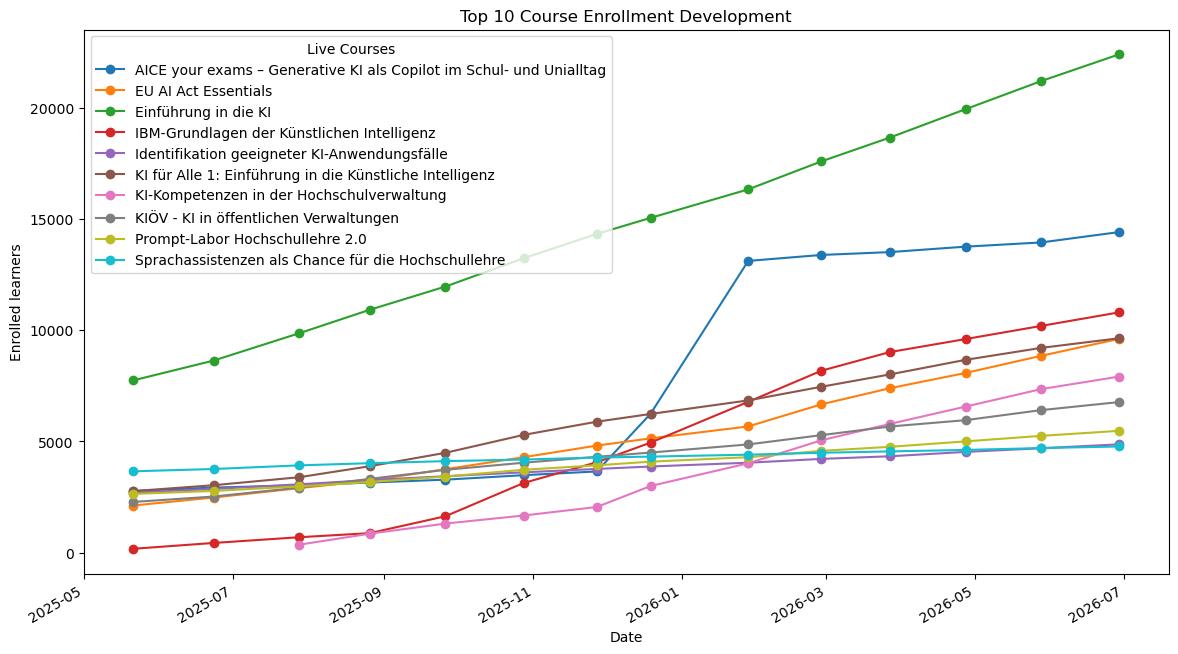

In [23]:
# plot timeseries of the top 10 courses

top10_enrol_allTime_pivot.plot(figsize = (14, 8), marker = 'o')

plt.xlabel('Date')
plt.ylabel('Enrolled learners')
plt.title('Top 10 Course Enrollment Development')
plt.show()
    

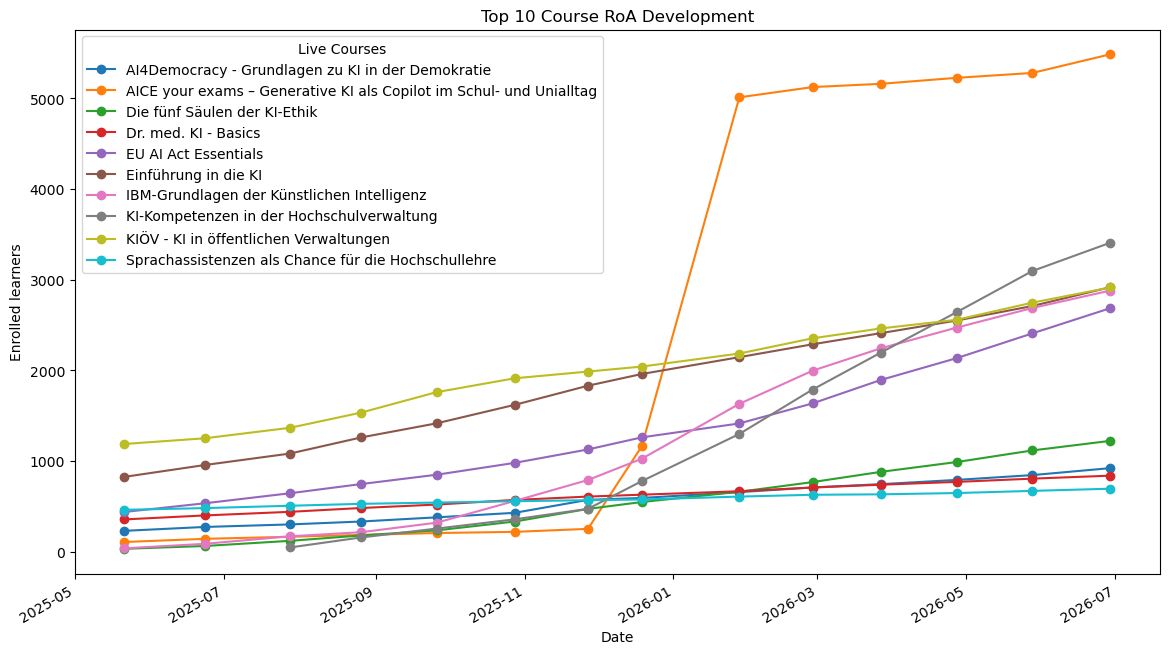

In [24]:
# top10 RoA

top10_RoA_allTime_pivot.plot(figsize = (14, 8), marker = 'o')

plt.xlabel('Date')
plt.ylabel('Enrolled learners')
plt.title('Top 10 Course RoA Development')
plt.show()

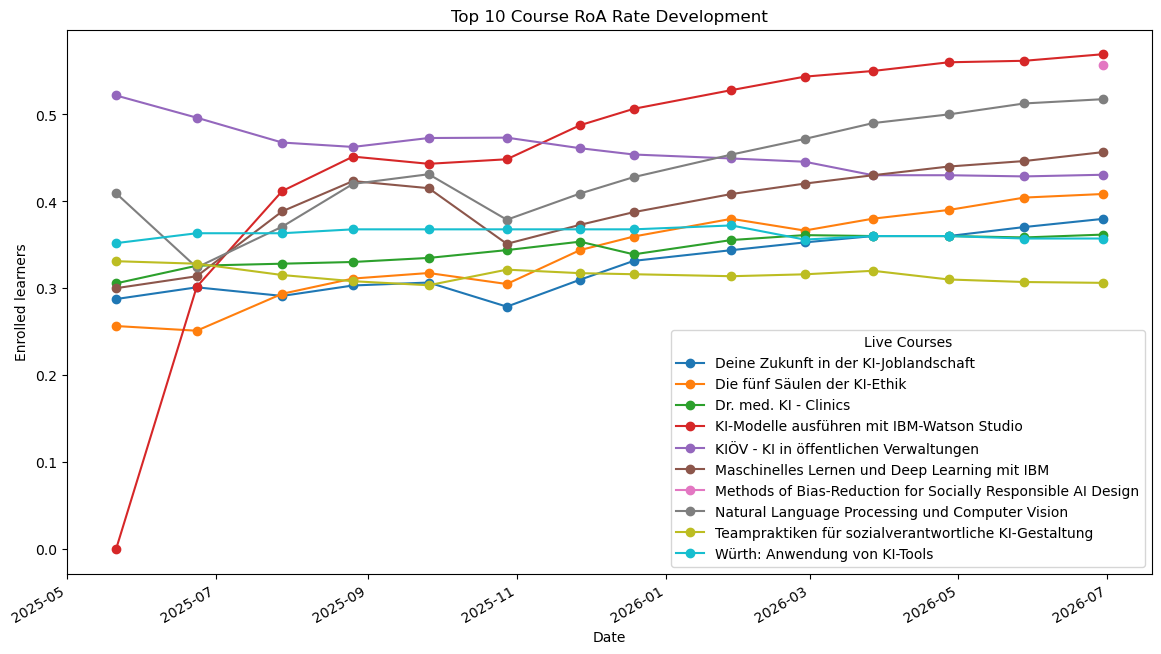

In [25]:
# Top 10 RoA Rate

top10_RoA_rate_allTime_pivot.plot(figsize = (14, 8), marker = 'o')

plt.xlabel('Date')
plt.ylabel('Enrolled learners')
plt.title('Top 10 Course RoA Rate Development')
plt.show()
    

In [26]:
# identify the least enroled courses across different months
# pivot enrolment, RoA and RoA rate
alltime_pivot_enrol = course_df.pivot(index = 'date', columns = 'Live Courses', values = 'Enrolled learners')

#alltime_pivot_enrol = alltime_pivot_enrol.sort_values('date', ascending = False)
print(alltime_pivot_enrol.shape)

alltime_pivot_RoA = course_df.pivot(index = 'date', columns = 'Live Courses', values = 'RoA')

#alltime_pivot_RoA = alltime_pivot_RoA.sort_values('date', ascending = False)
print(alltime_pivot_RoA.shape)


(14, 109)
(14, 109)


In [45]:
# get the courses with the least avg enrol in the past 6 months

alltime_enrol_diff = alltime_pivot_enrol.diff(axis = 0).sort_values('date', ascending = False)
alltime_RoA_diff = alltime_pivot_RoA.diff(axis = 0).sort_values('date', ascending = False)

halfYear_enrol_diff = alltime_enrol_diff.head(6)
halfYear_RoA_diff = alltime_RoA_diff.head(6)


In [46]:
# least avg enrol
halfYear_enrol_avg = pd.DataFrame(halfYear_enrol_diff.mean(axis = 0), columns = ['avg_enrol_diff'])
halfYear_RoA_avg = pd.DataFrame(halfYear_RoA_diff.mean(axis = 0), columns = ['avg_RoA_diff'])


In [47]:
# add courseID column
course_match = course_df[['courseID', 'Live Courses']].drop_duplicates()

course_match.shape

halfYear_enrol_avg = halfYear_enrol_avg.reset_index()
halfYear_RoA_avg = halfYear_RoA_avg.reset_index()


In [48]:
halfYear_enrol_avg = course_match.merge(halfYear_enrol_avg, how = 'left', on = 'Live Courses', validate = '1:1')
halfYear_RoA_avg = course_match.merge(halfYear_RoA_avg, how = 'left', on = 'Live Courses', validate = '1:1')

In [49]:
halfYear_enrol_avg = halfYear_enrol_avg.sort_values(by = 'avg_enrol_diff', ascending = True)
halfYear_RoA_avg = halfYear_RoA_avg.sort_values(by = 'avg_RoA_diff', ascending = True)

In [50]:
halfYear_enrol_avg.head()

,courseID,Live Courses,avg_enrol_diff
53,164,Würth: Erweiterte KI-Kompetenz,-0.166667
101,95,Launchpad to AI - An Introduction to Applicati...,0.000000
58,250,Künstliche Intelligenz im Kontext von Praxis u...,0.000000
46,248,Würth: Anwendung von KI-Tools,2.500000
57,242,Methods of AI V – Constraint Reasoning,5.333333


In [51]:
# export the halfYear data
#halfYear_enrol_avg.to_excel('C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Course_success_tracking/halfYear_enrol.xlsx')
#halfYear_RoA_avg.to_excel('C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/Course_success_tracking/halfYear_RoA.xlsx')

## Analysis per course category

In [219]:
# Aggregation of enrolment per category

print(f"# of total course category: {course_df['Course Category'].nunique()}")

# the number of courses in each category
course_df.groupby('Course Category')['Live Courses'].nunique()


# of total course category: 11


Course Category
Data Literacy           6
Erwachsenenbildung      4
Handel                  1
Industrie 4.0          10
KI und Ethik            7
Maschinelles Lernen    17
Medizin                10
Robotik                 1
Schule                 12
Studieren              19
Über KI                22
Name: Live Courses, dtype: int64

In [220]:
# average course enrolment per category

course_per_cat= pd.DataFrame(course_df.groupby('Course Category').agg(num_courses = ('Live Courses', 'nunique'), avg_enrol = ('Enrolled learners', 'mean'), avg_RoA = ('RoA', 'mean'), avg_RoA_rate = ('Rate RoA', 'mean')))

course_per_cat

,num_courses,avg_enrol,avg_RoA,avg_RoA_rate
Course Category,,,,
Data Literacy,6,1336.085366,281.172840,0.140846
Erwachsenenbildung,4,2858.288462,275.176471,0.070337
Handel,1,1452.857143,233.214286,0.159138
Industrie 4.0,10,1169.435714,97.362319,0.087212
KI und Ethik,7,1198.358974,278.525641,0.245561
Maschinelles Lernen,17,665.858025,75.050633,0.096755
Medizin,10,708.464286,137.142857,0.184968
Robotik,1,791.857143,5.000000,0.004258
Schule,12,725.839286,75.757576,0.124976


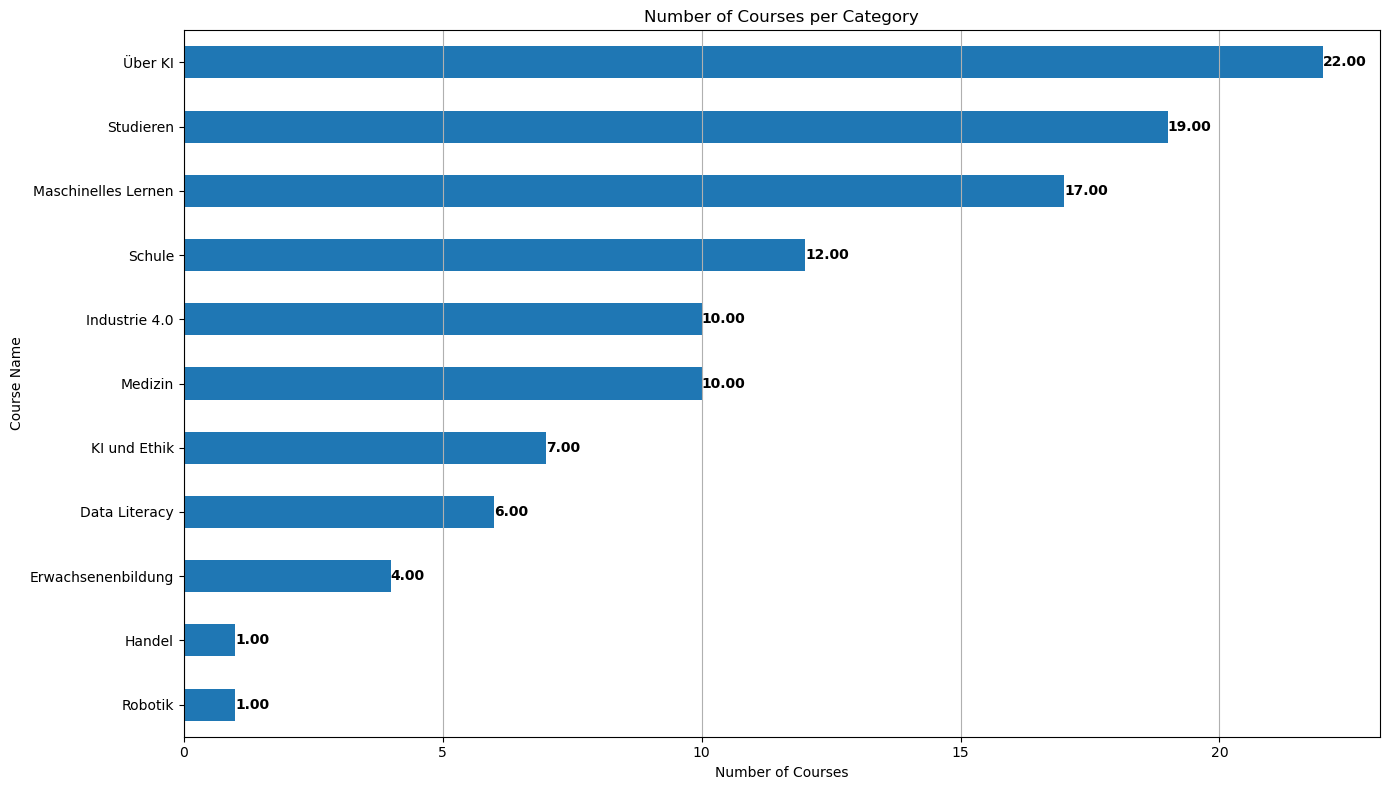

In [221]:
# plotting number of courses per category
plot_topX_horizontal('Number of Courses per Category', course_per_cat['num_courses'], xlabel = 'Number of Courses', x = 11, show_values = True)


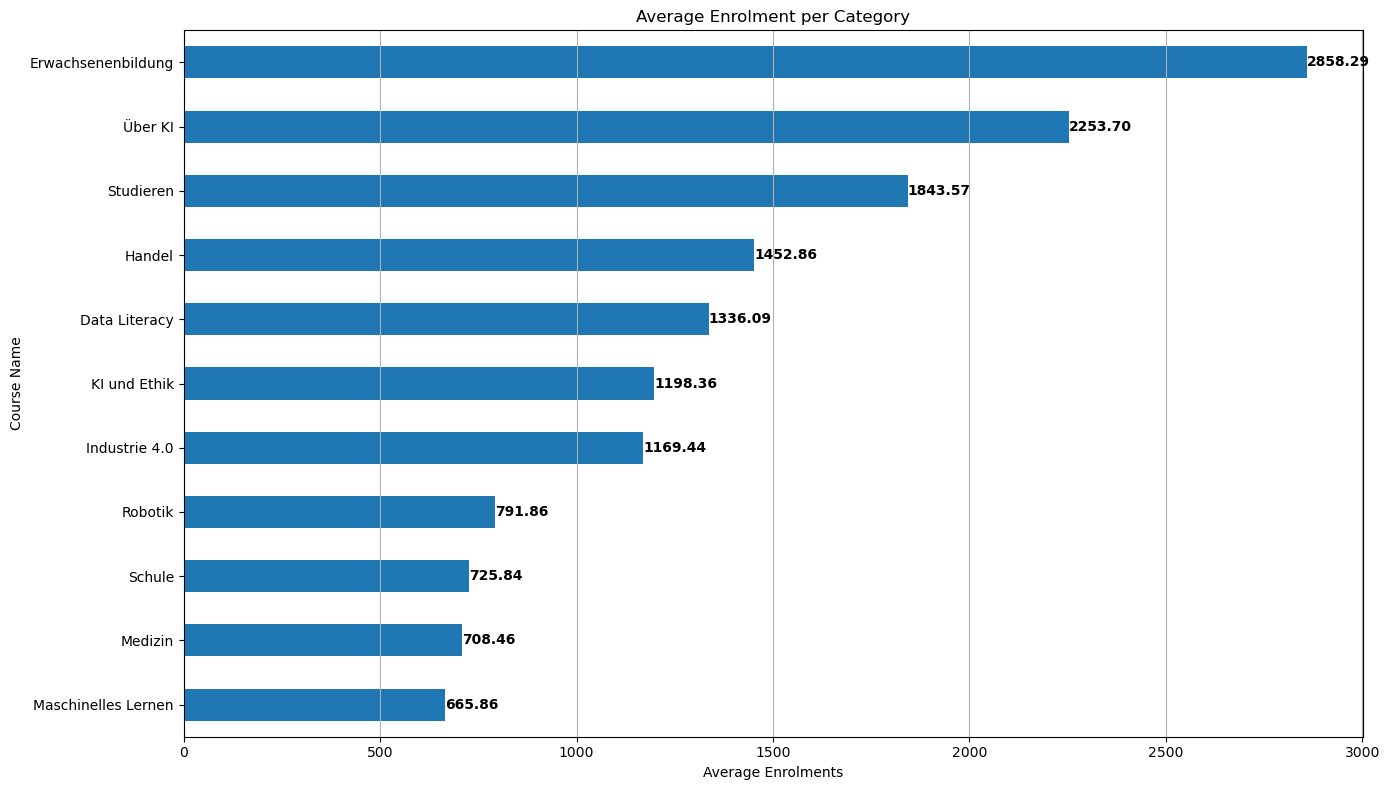

In [222]:
# plotting average enrol per category
plot_topX_horizontal('Average Enrolment per Category', course_per_cat['avg_enrol'], xlabel = 'Average Enrolments', x = 11, show_values = True)


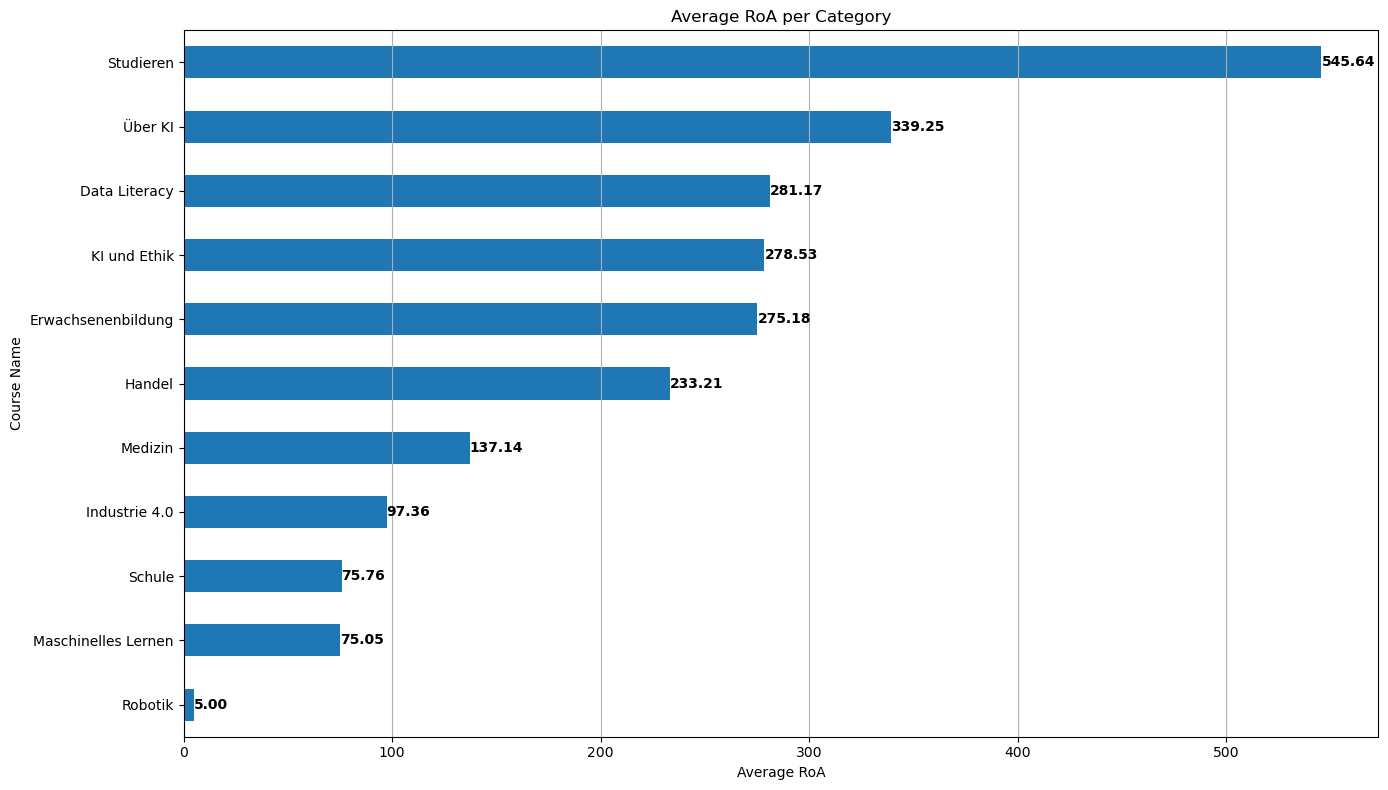

In [223]:
# plotting average RoA per category
plot_topX_horizontal('Average RoA per Category', course_per_cat['avg_RoA'], xlabel = 'Average RoA', x = 11, show_values = True)


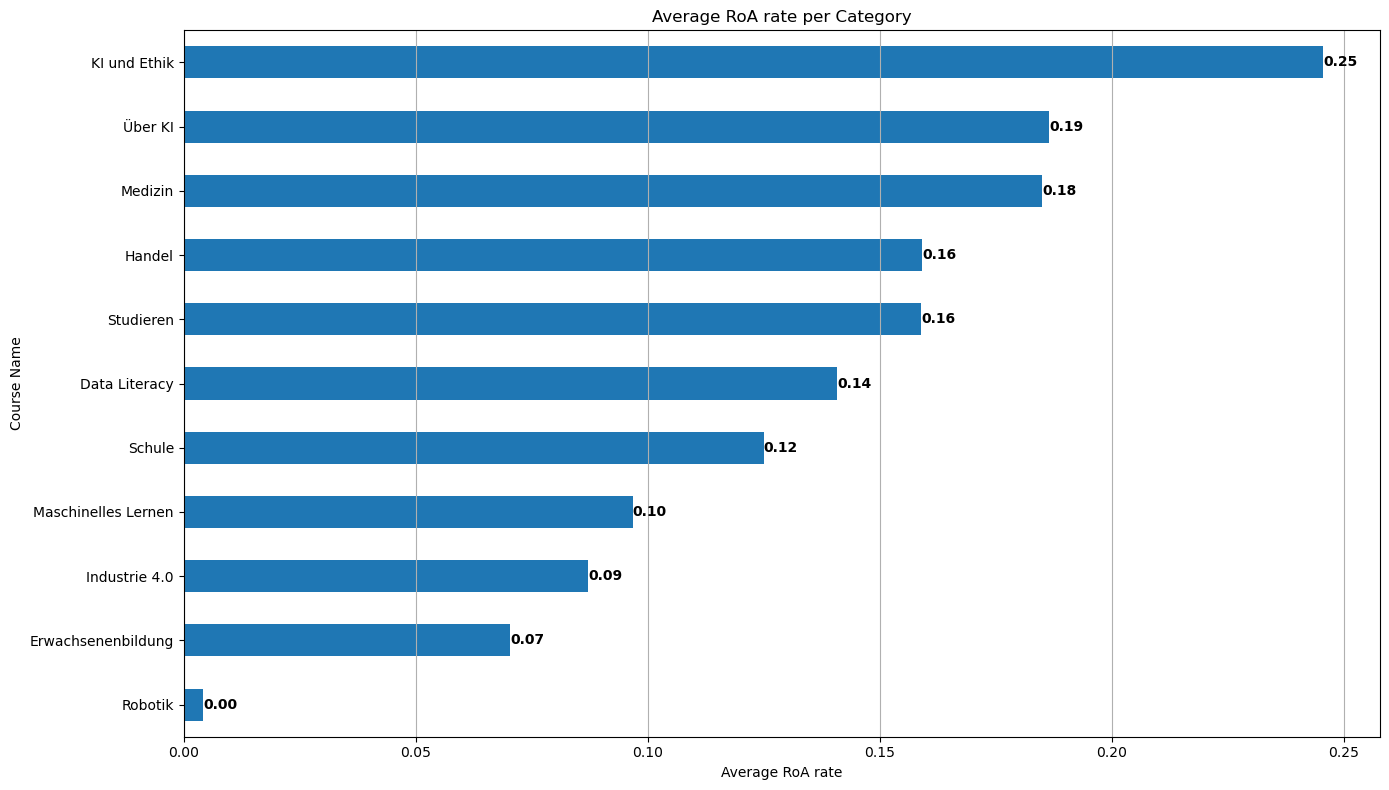

In [224]:
# plot average RoA rate per category
plot_topX_horizontal('Average RoA rate per Category', course_per_cat['avg_RoA_rate'], xlabel = 'Average RoA rate', x = 11, show_values = True)


In [225]:
# enrol per category
corr_per_cat= pd.DataFrame(course_df.groupby('Course Category')[['Enrolled learners', 'RoA', 'Rate RoA']].corr())

corr_per_cat

Enrolled learners       RoA  Rate RoA
Course Category                                                             
Data Literacy       Enrolled learners           1.000000  0.947581  0.640817
                    RoA                         0.947581  1.000000  0.779046
                    Rate RoA                    0.640817  0.779046  1.000000
Erwachsenenbildung  Enrolled learners           1.000000  0.929427  0.882540
                    RoA                         0.929427  1.000000  0.955290
                    Rate RoA                    0.882540  0.955290  1.000000
Handel              Enrolled learners           1.000000  0.987582  0.910879
                    RoA                         0.987582  1.000000  0.961474
                    Rate RoA                    0.910879  0.961474  1.000000
Industrie 4.0       Enrolled learners           1.000000  0.903873 -0.116461
                    RoA                         0.903873  1.000000  0.180250
                    Rate RoA                   -0.116461  0.180250  1.000000
KI und Ethik        Enrolled learners           1.000000  0.701822 -0.181101
                    RoA                         0.701822  1.000000  0.393519
                    Rate RoA                   -0.181101  0.393519  1.000000
Maschinelles Lernen Enrolled learners           1.000000  0.548039  0.154260
                    RoA                         0.548039  1.000000  0.773550
                    Rate RoA                    0.154260  0.773550  1.000000
Medizin             Enrolled learners           1.000000  0.974038  0.072106
                    RoA                         0.974038  1.000000  0.274432
                    Rate RoA                    0.072106  0.274432  1.000000
Robotik             Enrolled learners           1.000000  0.968413  0.908283
                    RoA                         0.968413  1.000000  0.954032
                    Rate RoA                    0.908283  0.954032  1.000000
Schule              Enrolled learners           1.000000  0.808438 -0.279050
                    RoA                         0.808438  1.000000  0.140921
                    Rate RoA                   -0.279050  0.140921  1.000000
Studieren           Enrolled learners           1.000000  0.960892  0.607777
                    RoA                         0.960892  1.000000  0.701354
                    Rate RoA                    0.607777  0.701354  1.000000
Über KI             Enrolled learners           1.000000  0.883524 -0.153946
                    RoA                         0.883524  1.000000  0.140402
                    Rate RoA                   -0.153946  0.140402  1.000000

<Axes: ylabel='Course Category-None'>

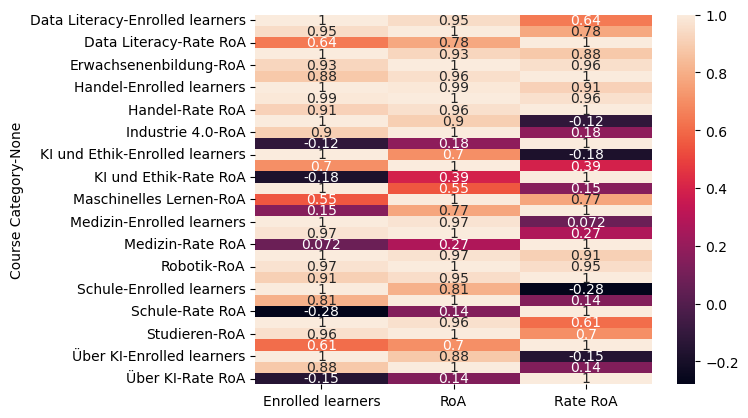

In [226]:
sns.heatmap(corr_per_cat, annot = True)

## Course workload & course language - CoP / RoA investigation

In [274]:
# course workload_language data path

workload_lang_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/workload_lang.csv'

workload_lang = pd.read_csv(workload_lang_path, sep = ';', encoding = 'utf-8')

print(workload_lang.info())

# change the dtype
workload_lang['workload_hrs'] = workload_lang['workload_hrs'].str.replace(',', '.').astype('float32')

workload_lang.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   courseID      104 non-null    int64 
 1   course        104 non-null    object
 2   workload_hrs  101 non-null    object
 3   lang          104 non-null    object
 4   num_section   104 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 4.2+ KB
None


,courseID,course,workload_hrs,lang,num_section
0,106,Einführung in die KI,40.0,DE,7
1,58,AICE your exams – Generative KI als Copilot im...,7.0,DE,7
2,99,KI für Alle 1: Einführung in die Künstliche In...,42.0,DE,21
3,313,EU AI Act Essentials,8.0,DE,6
4,197,KIÖV - KI in öffentlichen Verwaltungen,5.0,DE,6


In [281]:
# sanity check block
enrol_by_course_id.loc[enrol_by_course_id['courseID'] == 75]

,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA
17,75,AI Explorables for Schools,Schule,136.0,4.36,0.03


In [283]:
# merge with the course_df

course_workload_lang  = enrol_by_course_id.merge(workload_lang, how = 'left', on = ['courseID'])

course_workload_lang.head()

,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA,course,workload_hrs,lang,num_section
0,6,Introduction to Machine Learning Part 1: Found...,Maschinelles Lernen,1660.0,91.21,0.05,Introduction to Machine Learning Part 1: Found...,40.0,EN,6
1,10,Dr. med. KI - Ethics,Medizin,636.0,183.50,0.28,Dr. med. KI - Ethics,21.0,DE,9
2,19,Sprachassistenzen als Chance für die Hochschul...,Erwachsenenbildung,4266.0,576.79,0.13,Sprachassistenzen als Chance für die Hochschul...,5.0,DE,5
3,27,Identifikation geeigneter KI-Anwendungsfälle,Industrie 4.0,3799.0,299.71,0.08,Identifikation geeigneter KI-Anwendungsfälle,15.0,DE,11
4,28,Künstliche Intelligenz im Handel,Handel,1453.0,233.21,0.16,Künstliche Intelligenz im Handel,12.0,DE,9


In [284]:
# Deal with missing values & exclude course col
course_workload_lang[course_workload_lang['workload_hrs'].isna()]


,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA,course,workload_hrs,lang,num_section
39,164,Würth: Erweiterte KI-Kompetenz,Über KI,156.0,30.93,0.20,Würth: Erweiterte KI-Kompetenz,NaN,DE,8
74,248,Würth: Anwendung von KI-Tools,Über KI,228.0,82.50,0.36,Würth: Anwendung von KI-Tools,NaN,DE,5
75,250,Künstliche Intelligenz im Kontext von Praxis u...,Medizin,79.0,6.07,0.08,Künstliche Intelligenz im Kontext von Praxis u...,NaN,DE,9


In [285]:
#course_workload_lang = course_workload_lang.drop(['course'], axis = 1)
print(course_workload_lang.shape)
course_workload_lang = course_workload_lang.dropna()
print(course_workload_lang.shape)

course_workload_lang.head()

(110, 10)
(107, 10)


,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA,course,workload_hrs,lang,num_section
0,6,Introduction to Machine Learning Part 1: Found...,Maschinelles Lernen,1660.0,91.21,0.05,Introduction to Machine Learning Part 1: Found...,40.0,EN,6
1,10,Dr. med. KI - Ethics,Medizin,636.0,183.50,0.28,Dr. med. KI - Ethics,21.0,DE,9
2,19,Sprachassistenzen als Chance für die Hochschul...,Erwachsenenbildung,4266.0,576.79,0.13,Sprachassistenzen als Chance für die Hochschul...,5.0,DE,5
3,27,Identifikation geeigneter KI-Anwendungsfälle,Industrie 4.0,3799.0,299.71,0.08,Identifikation geeigneter KI-Anwendungsfälle,15.0,DE,11
4,28,Künstliche Intelligenz im Handel,Handel,1453.0,233.21,0.16,Künstliche Intelligenz im Handel,12.0,DE,9


In [286]:
course_workload_lang = course_workload_lang.drop('course', axis = 1)

course_workload_lang.describe()

,courseID,Avg_enrol,Avg_RoA,Avg_rate_RoA,workload_hrs,num_section
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,205.672897,1236.411215,200.393364,0.135701,24.873833,9.018692
std,108.946826,1922.470884,405.791349,0.112477,38.222488,3.892376
min,6.000000,16.000000,0.000000,0.000000,1.500000,4.000000
25%,110.000000,259.000000,14.675000,0.060000,7.500000,6.000000
50%,228.000000,636.000000,54.000000,0.110000,12.000000,8.000000
75%,271.000000,1448.000000,183.105000,0.180000,27.500000,10.000000
max,420.000000,14845.000000,2407.290000,0.560000,300.000000,23.000000


In [287]:
# correaltion matrix for numerical variables
num_course_workload = course_workload_lang[['Avg_enrol', 'Avg_RoA', 'Avg_rate_RoA', 'workload_hrs']].corr()

num_course_workload


,Avg_enrol,Avg_RoA,Avg_rate_RoA,workload_hrs
Avg_enrol,1.000000,0.815108,0.080658,-0.059225
Avg_RoA,0.815108,1.000000,0.405204,-0.146268
Avg_rate_RoA,0.080658,0.405204,1.000000,-0.249309
workload_hrs,-0.059225,-0.146268,-0.249309,1.000000


<Axes: >

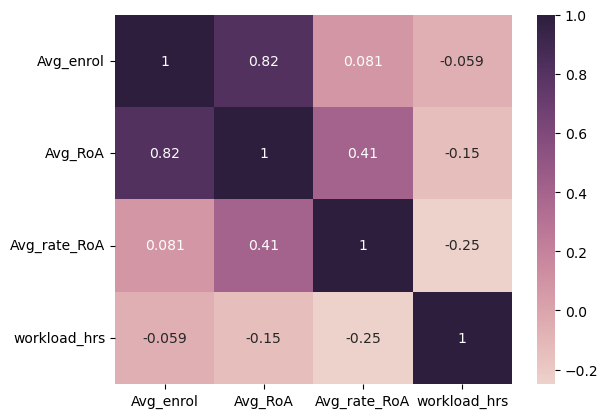

In [288]:
sns.heatmap(num_course_workload, annot = True, cmap = sns.cubehelix_palette(as_cmap=True))

* the average RoA has a strong positive correlation with the average enrolment r = 0.82
* the average RoA rate has a very weak negative correlation with the average enrolment r = 0.081
* the average workload has a very weak negative correlation with the average enrolment r = -0.059
* the average RoA rate has a moderate positive correlation with the average RoA r = 0.41
* the average workload has a weak negative correlation with the average RoA r = -0.15
* the average workload has a weak negative correlation with the average RoA rate r = -0.25

In [289]:
# function - iqr calculator
def iqr_calculator(x):
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr 
    return (iqr, upper, lower)

IQR: 20.0 Upper: 57.5


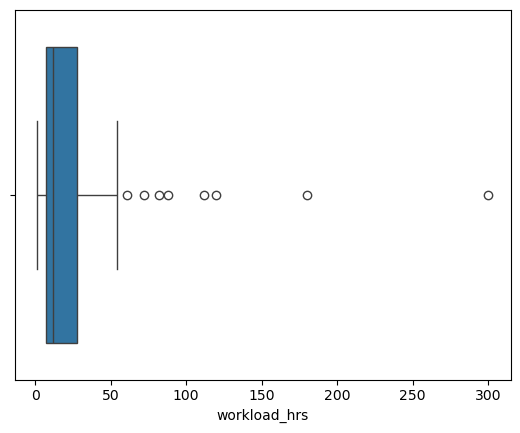

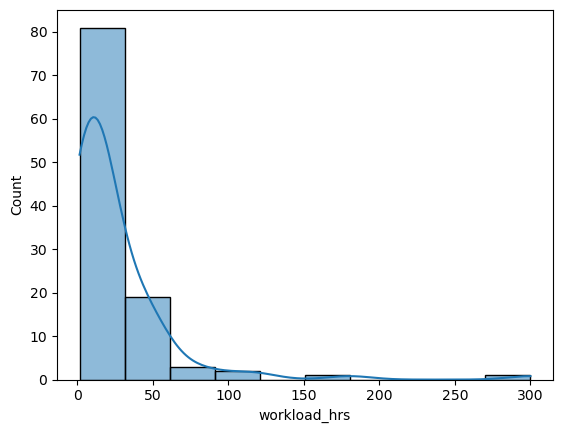

In [300]:
# descriptive stats of the workload distributions and language distributions
print('IQR:', str(iqr_calculator(course_workload_lang['workload_hrs'])[0]), 'Upper:', str(iqr_calculator(course_workload_lang['workload_hrs'])[1]))

sns.boxplot(x = 'workload_hrs', data = course_workload_lang)
plt.show()

sns.histplot(x = 'workload_hrs', data = course_workload_lang, kde = True, bins = 10)
plt.show()

In [291]:
# descriptive stats of the workload distributions by category
workload_cat = pd.DataFrame(course_workload_lang.groupby('Course Category')['workload_hrs'].agg([np.mean, np.std]))

workload_cat['mean'] = round(workload_cat['mean'], 2)
workload_cat['std'] = round(workload_cat['std'], 2)

print(workload_cat)

                           mean        std
Course Category                           
Data Literacy         20.830000  16.170000
Erwachsenenbildung     9.250000   3.400000
Handel                12.000000        NaN
Industrie 4.0         27.100000  21.549999
KI und Ethik           4.500000   4.190000
Maschinelles Lernen   40.910000  34.270000
Medizin               24.000000  18.790001
Robotik              180.000000        NaN
Schule                39.310001  79.930000
Studieren             16.920000  19.709999
Über KI               13.050000  15.580000


C:\Users\ywa\AppData\Local\Temp\ipykernel_12024\1281179003.py:2: FutureWarning: The provided callable <function mean at 0x000002DA7082F6A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  workload_cat = pd.DataFrame(course_workload_lang.groupby('Course Category')['workload_hrs'].agg([np.mean, np.std]))
C:\Users\ywa\AppData\Local\Temp\ipykernel_12024\1281179003.py:2: FutureWarning: The provided callable <function std at 0x000002DA7082F7E0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  workload_cat = pd.DataFrame(course_workload_lang.groupby('Course Category')['workload_hrs'].agg([np.mean, np.std]))


*  ML courses and Robotic course has the highest average course workload.
*  The KI und Ethik courses have the least average course workload. 
*  Except for the Schule, ML and Robotic courses, most of the courses are below 25 hrs workload

In [293]:
# descriptive stats of the workload distributions by language
workload_language = pd.DataFrame(course_workload_lang.groupby('lang')['workload_hrs'].agg([np.mean, np.std]))

workload_language['mean'] = round(workload_language['mean'], 2)
workload_language['std'] = round(workload_language['std'], 2)

print(workload_language)


           mean        std
lang                      
DE    21.410000  37.240002
EN    32.310001  39.799999


C:\Users\ywa\AppData\Local\Temp\ipykernel_12024\1730254138.py:2: FutureWarning: The provided callable <function mean at 0x000002DA7082F6A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  workload_language = pd.DataFrame(course_workload_lang.groupby('lang')['workload_hrs'].agg([np.mean, np.std]))
C:\Users\ywa\AppData\Local\Temp\ipykernel_12024\1730254138.py:2: FutureWarning: The provided callable <function std at 0x000002DA7082F7E0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  workload_language = pd.DataFrame(course_workload_lang.groupby('lang')['workload_hrs'].agg([np.mean, np.std]))


### Do courses in different languages perform differently?

Text(0.5, 1.0, 'Average Enrolment in English and German courses')

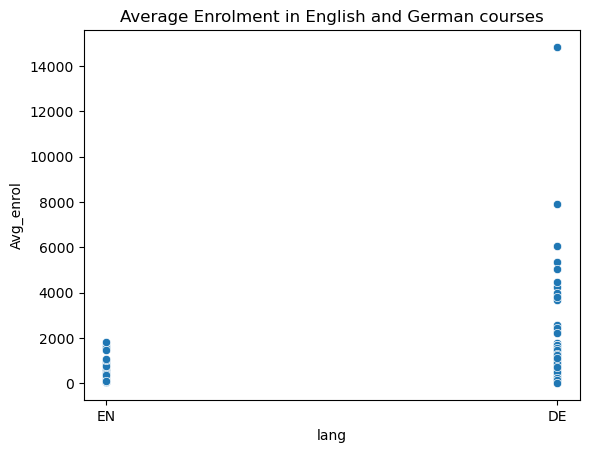

In [294]:
sns.scatterplot(x = 'lang', y = 'Avg_enrol', data = course_workload_lang)
plt.title("Average Enrolment in English and German courses")

Text(0.5, 1.0, 'Average RoA obtained in English and German courses')

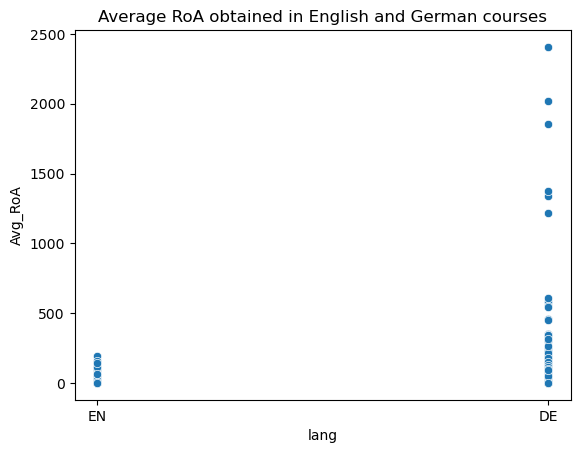

In [295]:
sns.scatterplot(x = 'lang', y = 'Avg_RoA', data = course_workload_lang)
plt.title("Average RoA obtained in English and German courses")

Text(0.5, 1.0, 'Average RoA rate in English and German courses')

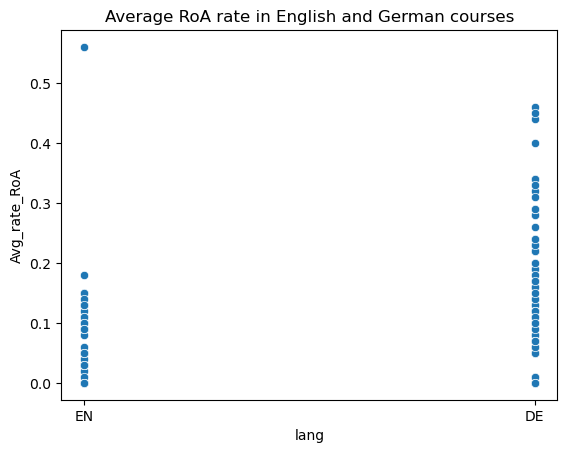

In [296]:
sns.scatterplot(x = 'lang', y = 'Avg_rate_RoA', data = course_workload_lang)
plt.title("Average RoA rate in English and German courses")

## Cluster analysis

In [297]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [298]:
# import dependencies
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [243]:
# feature selection 
course_workload_lang.head()

cluster_feature = course_workload_lang.drop(['courseID', 'Live Courses'], axis = 1)

cluster_feature.info()


<class 'pandas.core.frame.DataFrame'>
Index: 103 entries, 0 to 108
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Course Category  103 non-null    object 
 1   Avg_enrol        103 non-null    float64
 2   Avg_RoA          103 non-null    float64
 3   Avg_rate_RoA     103 non-null    float64
 4   workload_hrs     103 non-null    float32
 5   lang             103 non-null    object 
 6   num_section      103 non-null    float64
dtypes: float32(1), float64(4), object(2)
memory usage: 6.0+ KB


In [244]:
# encoding scaling data via column transformer

preprocess = ColumnTransformer(transformers = [('categorical', OneHotEncoder(drop = 'if_binary'), ['Course Category', 'lang']), 
                                               ('numerical', StandardScaler(), ['Avg_enrol', 'Avg_RoA', 'Avg_rate_RoA', 'workload_hrs'])])



In [245]:
# setup param_finder function
random_state = 777

def param_finder(n_list, k_list, random_state, features):
    best_score = -1
    best_param = None
    results = []
    for n in n_list:
        pca = PCA(n_components = n, random_state = random_state)
        X_reduced = pca.fit_transform(features)
        
        for k in k_list:
            kmeans = KMeans(n_clusters = k, random_state = random_state, n_init = 20)
            labels = kmeans.fit_predict(X_reduced)
            
            score = silhouette_score(X_reduced, labels)
            results.append((n, k, score))
            
            if score > best_score:
                best_score = score
                best_param = {'n_components' : n, 'k' : k}
    return best_score, best_param, results

In [246]:
# iterate features through function

features = preprocess.fit_transform(cluster_feature)

print(features.shape)

n_list = np.arange(5, 20, 5)
k_list = range(2, 9)

best_score, best_param, results = param_finder(n_list, k_list, random_state, features)

print(best_score, best_param)


(103, 18)
0.5999096951753572 {'n_components': np.int64(5), 'k': 2}


In [247]:
# build pipeline PCA + KMeans --> feed the best hyperparam here

num_components = best_param['n_components']
k = best_param['k']

pipe = Pipeline([('preprocess', preprocess), 
                 ('pca', PCA(n_components = num_components)), 
                 ('kmeans', KMeans(n_clusters = k, n_init = 20, random_state = random_state ))])

labels = pipe.fit_predict(cluster_feature)

labels.shape


(103,)

In [248]:
# cluster stability
# interate the clustring with different random seeds calculate the Adjusted Rand Index (ARI)
# aim for ARI close to 1 (identical clustering)
# fucntion to get labels

def get_labels(X, n_components, k, runs = 20):
    label_list = []
    
    for seed in range(runs):
        pipe = Pipeline(steps = [('pca', PCA(n_components = n_components, random_state = seed)), 
                                ('kmeans', KMeans(n_clusters = k, random_state = seed, n_init = 20))])
        
        labels = pipe.fit_predict(X)
        label_list.append(labels)
    return label_list
 
def ari_calculator(label_list):
    n = len(label_list)
    ari_scores = []
    
    for i in range(n):
        for j in range(i + 1, n):
            ari = adjusted_rand_score(label_list[i], label_list[j])
            ari_scores.append(ari)
            
    return np.mean(ari_scores), np.std(ari_scores)


label_list = get_labels(features, best_param['n_components'], best_param['k'], runs = 20)
avg, std = ari_calculator(label_list)

print(f"average: {avg}, std: {std}")

average: 1.0, std: 0.0


In [249]:
# interpretation by bringing back the clusters back to the oringinal high dimensions
pca = pipe.named_steps['pca']
kmeans= pipe.named_steps['kmeans']

# get original centroids
centroids = pca.inverse_transform(kmeans.cluster_centers_)
print(centroids.shape)

(2, 18)


In [250]:
# inteprete within dataframe
centroids_df = pd.DataFrame(centroids, columns = preprocess.get_feature_names_out())

centroids_df


,categorical__Course Category_Data Literacy,categorical__Course Category_Erwachsenenbildung,categorical__Course Category_Handel,categorical__Course Category_Industrie 4.0,categorical__Course Category_KI und Ethik,categorical__Course Category_Maschinelles Lernen,categorical__Course Category_Medizin,categorical__Course Category_Robotik,categorical__Course Category_Schule,categorical__Course Category_Studieren,categorical__Course Category_Über KI,categorical__lang_DE,categorical__lang_DE/EN,categorical__lang_EN,numerical__Avg_enrol,numerical__Avg_RoA,numerical__Avg_rate_RoA,numerical__workload_hrs
0,0.055696,0.036074,0.009574,0.101224,0.068047,0.159257,0.090711,0.010420,0.123189,0.161281,0.184526,0.670312,0.010736,0.318952,-0.191080,-0.212846,-0.070061,0.022635
1,0.099584,0.083472,0.011895,0.030211,0.066573,-0.074660,0.033502,-0.001798,0.008442,0.559286,0.183493,0.996624,-0.006900,0.010276,3.089122,3.441006,1.132651,-0.365927


In [251]:
# compare with cluster frequency
features_df = pd.DataFrame(features, columns = preprocess.get_feature_names_out())

features_df['labels'] = labels
cluster_profiles = features_df.groupby('labels').mean()

cluster_profiles

,categorical__Course Category_Data Literacy,categorical__Course Category_Erwachsenenbildung,categorical__Course Category_Handel,categorical__Course Category_Industrie 4.0,categorical__Course Category_KI und Ethik,categorical__Course Category_Maschinelles Lernen,categorical__Course Category_Medizin,categorical__Course Category_Robotik,categorical__Course Category_Schule,categorical__Course Category_Studieren,categorical__Course Category_Über KI,categorical__lang_DE,categorical__lang_DE/EN,categorical__lang_EN,numerical__Avg_enrol,numerical__Avg_RoA,numerical__Avg_rate_RoA,numerical__workload_hrs
labels,,,,,,,,,,,,,,,,,,
0,0.051546,0.041237,0.010309,0.103093,0.072165,0.154639,0.092784,0.010309,0.123711,0.164948,0.175258,0.670103,0.010309,0.319588,-0.179426,-0.225289,-0.065760,0.022570
1,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.333333,1.000000,0.000000,0.000000,2.900718,3.642172,1.063122,-0.364876


In [252]:
# get top 5 features --> what contribute to the difference
for i, row in centroids_df.iterrows():
    print(f"\nCluster{i} in pre set")
    print(row.sort_values(ascending = False).head(5))


Cluster0 in pre set
categorical__lang_DE                                0.670312
categorical__lang_EN                                0.318952
categorical__Course Category_Über KI                0.184526
categorical__Course Category_Studieren              0.161281
categorical__Course Category_Maschinelles Lernen    0.159257
Name: 0, dtype: float64

Cluster1 in pre set
numerical__Avg_RoA                        3.441006
numerical__Avg_enrol                      3.089122
numerical__Avg_rate_RoA                   1.132651
categorical__lang_DE                      0.996624
categorical__Course Category_Studieren    0.559286
Name: 1, dtype: float64


In [253]:
# get importance (cluster mean - global mean)
global_mean = features_df.mean()

importance = cluster_profiles - global_mean

for i, row in importance.iterrows():
    print(f"\nCluster{i} in pre set (importance)")
    print(row.sort_values(ascending = False).head(5))


Cluster0 in pre set (importance)
numerical__workload_hrs                             0.022570
categorical__lang_EN                                0.018617
categorical__Course Category_Maschinelles Lernen    0.009008
categorical__Course Category_Schule                 0.007206
categorical__Course Category_Industrie 4.0          0.006005
Name: 0, dtype: float64

Cluster1 in pre set (importance)
numerical__Avg_RoA                        3.642172
numerical__Avg_enrol                      2.900718
numerical__Avg_rate_RoA                   1.063122
categorical__Course Category_Studieren    0.315534
categorical__lang_DE                      0.310680
Name: 1, dtype: float64


In [254]:
# plotting with TSNE
pca4embed = PCA(n_components = 5)

embed = pca4embed.fit_transform(features)
tsne = TSNE(n_components = 2, learning_rate = 'auto', init = 'pca', 
                 perplexity = 30, random_state = random_state).fit_transform(embed)


In [255]:
# plotting function
def plotting_clusters(labels, tsne):
    plt.figure()
    plt.scatter(tsne[:, 0], tsne[:, 1], c = labels, s = 8) # plotting points
    # plotting centroids (median)
    for c in np.unique(labels):
        pts = tsne[labels == c]
        centre = np.median(pts, axis = 0)
        plt.scatter(centre[0], centre[1], s = 250, marker = 'X')
        plt.text(centre[0], centre[1], f"C{c}", fontsize = 12, color = 'red', fontweight = 'bold')
    plt.title('t-SNE with Cluster Centres (median in t-SNE space)')
    plt.show()


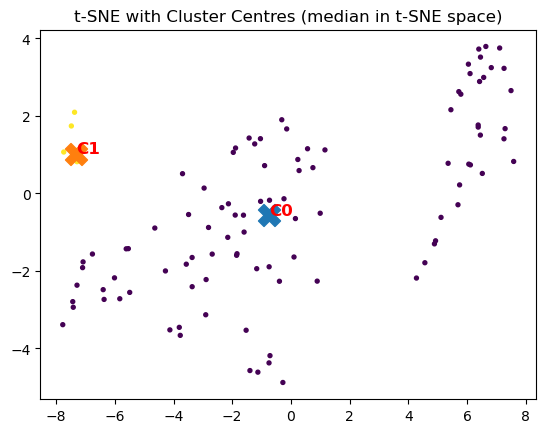

In [256]:
plotting_clusters(labels, tsne)

In [257]:
#  check labels
np.bincount(labels)

array([97,  6])

In [258]:
# zoom in on the outlier group
course_workload_lang['labels'] = labels

outliers = course_workload_lang.loc[course_workload_lang['labels'] == 1]

outliers

,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA,workload_hrs,lang,num_section,labels
11,58,AICE your exams – Generative KI als Copilot im...,Studieren,7900.0,2407.29,0.20,7.0,DE,7.0,1
24,106,Einführung in die KI,Über KI,14845.0,1853.29,0.12,40.0,DE,7.0,1
44,197,KIÖV - KI in öffentlichen Verwaltungen,Studieren,4465.0,2016.93,0.46,5.0,DE,6.0,1
87,313,EU AI Act Essentials,Studieren,5353.0,1337.79,0.24,8.0,DE,6.0,1
89,322,IBM-Grundlagen der Künstlichen Intelligenz,Über KI,5034.0,1220.71,0.23,1.5,DE,9.0,1
97,360,KI-Kompetenzen in der Hochschulverwaltung,Data Literacy,3822.0,1372.92,0.29,3.0,DE,6.0,1
